In [53]:
#Amazon Customer Sentiment Analysis

#Objective
#Analyze Amazon customer reviews and classify them into positive and negative sentiments using Natural Language Processing and Machine Learning.

In [51]:
!pip install nltk wordcloud

In [ ]:
# 1. Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [54]:
# 2. Load Dataset

In [10]:
df = pd.read_csv('/amazon_books_Data.csv')

In [55]:
# 3. Explore Dataset

In [11]:
df.head()

,Unnamed: 0,market_place,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,Sentiment_books,review_month,review_day,review_year
0,0,"""US""","""25933450""","""RJOVP071AVAJO""","""0439873800""","""84656342""","""There Was an Old Lady Who Swallowed a Shell!""","""Books""",1,0,0,0 \t(N),1 \t(Y),"""Five Stars""","""I love it and so does my students!""",2015-08-31,positive,August,Monday,2015
1,1,"""US""","""1801372""","""R1ORGBETCDW3AI""","""1623953553""","""729938122""","""I Saw a Friend""","""Books""",1,0,0,0 \t(N),1 \t(Y),"""Please buy ""I Saw a Friend""! Your children wi...","""My wife and I ordered 2 books and gave them a...",2015-08-31,positive,August,Monday,2015
2,2,"""US""","""5782091""","""R7TNRFQAOUTX5""","""142151981X""","""678139048""","""Black Lagoon, Vol. 6""","""Books""",1,0,0,0 \t(N),1 \t(Y),"""Shipped fast.""","""Great book just like all the others in the se...",2015-08-31,positive,August,Monday,2015
3,3,"""US""","""32715830""","""R2GANXKDIFZ6OI""","""014241543X""","""712432151""","""If I Stay""","""Books""",1,0,0,0 \t(N),0 \t(N),"""Five Stars""","""So beautiful""",2015-08-31,positive,August,Monday,2015
4,4,"""US""","""14005703""","""R2NYB6C3R8LVN6""","""1604600527""","""800572372""","""Stars 'N Strips Forever""","""Books""",1,2,2,0 \t(N),1 \t(Y),"""Five Stars""","""Enjoyed the author's story and his quilts are...",2015-08-31,positive,August,Monday,2015


In [12]:
df.shape

(100, 20)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         100 non-null    int64 
 1   market_place       100 non-null    object
 2   customer_id        100 non-null    object
 3   review_id          100 non-null    object
 4   product_id         100 non-null    object
 5   product_parent     100 non-null    object
 6   product_title      100 non-null    object
 7   product_category   100 non-null    object
 8   star_rating        100 non-null    int64 
 9   helpful_votes      100 non-null    int64 
 10  total_votes        100 non-null    int64 
 11  vine               100 non-null    object
 12  verified_purchase  100 non-null    object
 13  review_headline    100 non-null    object
 14  review_body        100 non-null    object
 15  review_date        100 non-null    object
 16  Sentiment_books    100 non-null    object
 17

In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
market_place,0
customer_id,0
review_id,0
product_id,0
product_parent,0
product_title,0
product_category,0
star_rating,0
helpful_votes,0


In [56]:
# 4. Data Cleaning

In [15]:
df.dropna(inplace=True)

In [16]:
df.drop_duplicates(inplace=True)

In [57]:
# 5. Sentiment Labeling

In [17]:
def sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

In [19]:
print(df.columns)

Index(['Unnamed: 0', 'market_place', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date', 'Sentiment_books',
       'review_month', 'review_day', 'review_year'],
      dtype='object')


In [58]:
# 5. Sentiment Labeling

In [20]:
df['Sentiment'] = df['star_rating'].apply(sentiment)

In [59]:
# 6. Text Preprocessing

In [21]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Cleaned_Review'] = df['review_body'].apply(clean_text)

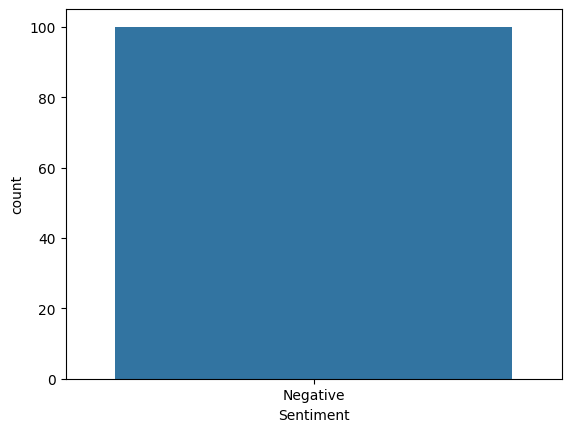

In [22]:
sns.countplot(x='Sentiment', data=df)
plt.show()

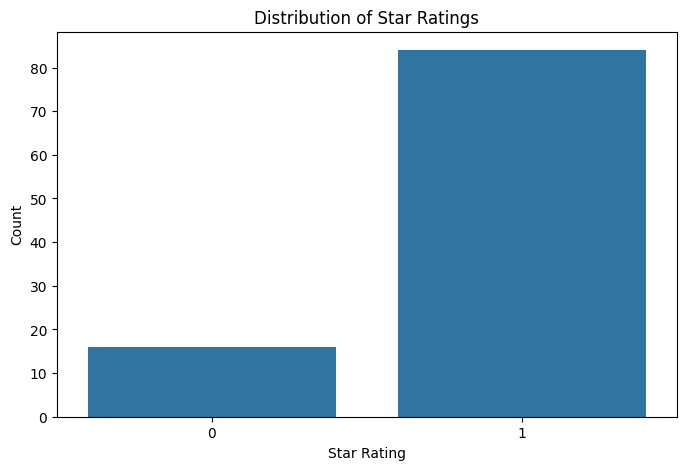

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='star_rating', data=df)
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.title('Distribution of Star Ratings')
plt.show()

In [60]:
# 5. Sentiment Labeling

In [27]:
print(df['Sentiment'].value_counts())

Sentiment
Negative    100
Name: count, dtype: int64


In [28]:
print(df['Sentiment'].value_counts())

Sentiment
Negative    100
Name: count, dtype: int64


In [61]:
# 6. Text Preprocessing

In [29]:
print(df['Cleaned_Review'].head())

0                                        love students
1    wife ordered books gave presents one friend da...
2                        great book like others series
3                                            beautiful
4    enjoyed author story quilts incredible plans m...
Name: Cleaned_Review, dtype: object


In [30]:
print(df['Cleaned_Review'].isnull().sum())

0


In [31]:
positive_reviews = df[df['Sentiment']=='Positive']['Cleaned_Review']

positive_words = " ".join(
    positive_reviews.dropna().astype(str)
)

In [33]:
print(df['Sentiment'].unique())

['Negative']


In [34]:
print(df['Sentiment'].value_counts())

Sentiment
Negative    100
Name: count, dtype: int64


In [36]:
print(df['star_rating'].unique())
print(df['star_rating'].value_counts())

[1 0]
star_rating
1    84
0    16
Name: count, dtype: int64


In [37]:
def sentiment(rating):
    if rating == 1:
        return "Positive"
    else:
        return "Negative"

df['Sentiment'] = df['star_rating'].apply(sentiment)

In [38]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    84
Negative    16
Name: count, dtype: int64


In [39]:
positive_reviews = df[df['Sentiment']=='Positive']['Cleaned_Review']

positive_words = " ".join(positive_reviews.dropna().astype(str))

In [63]:
# 8. Word Cloud Visualization

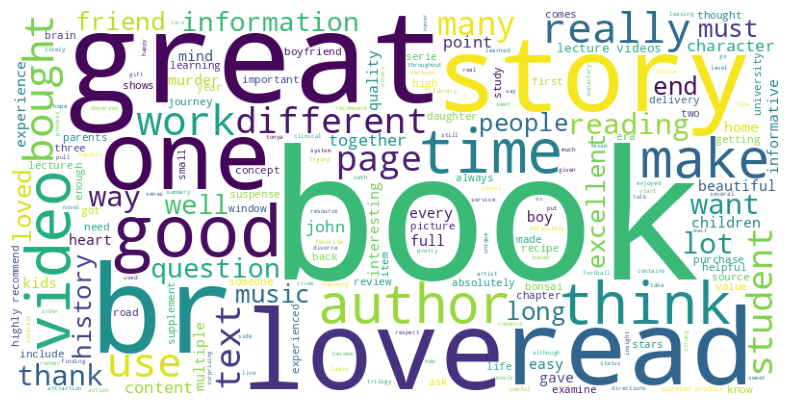

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [64]:
# 9. Feature Extraction using TF-IDF

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Cleaned_Review'])

y = df['Sentiment']

In [65]:
# 10. Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
# 11. Model Training using Naive Bayes

In [43]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [44]:
y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.85      1.00      0.92        17

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [67]:
# 12. Model Prediction

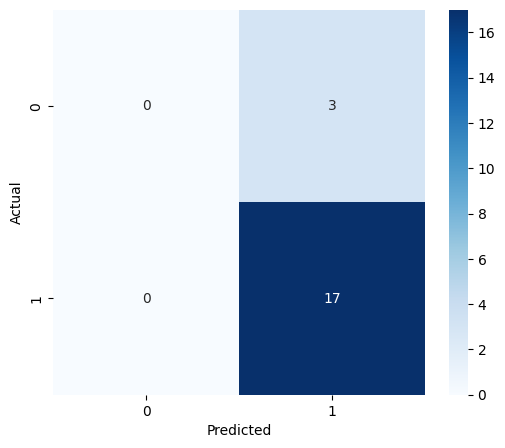

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [68]:
# 14. Save Model

In [47]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))

In [48]:
import pickle

pickle.dump(model, open('sentiment_model.pkl', 'wb'))

In [ ]:
# Conclusion

This project analyzes Amazon customer reviews and classifies them into positive and negative sentiments. The text data was preprocessed and transformed into numerical features using TF-IDF. A Multinomial Naive Bayes classifier was trained to predict sentiment effectively. This model can help businesses understand customer opinions and improve products based on feedback.